In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

from human_gastruloid_analysis import *

sc.set_figure_params(figsize=(5, 5))

In [2]:
def strip_project_path(path: str):
    cwd = os.getcwd()
    return path[cwd.index("human-gastruloid-analysis") :]


cwd = os.getcwd()
print("Current working folder: " + strip_project_path(cwd))
data_dir = Path("../data")
model_dir = Path("../src/human_gastruloid_analysis/models")
print("Data folder: " + strip_project_path(str(data_dir.resolve())))
print("Model folder: " + strip_project_path(str(model_dir.resolve())))

Current working folder: human-gastruloid-analysis/notebooks
Data folder: human-gastruloid-analysis/data
Model folder: human-gastruloid-analysis/src/human_gastruloid_analysis/models


In [6]:
# All available datasets
list_data()

IH-2025-nature  (8 file(s), needs unzip)
paper : https://www.nature.com/articles/s41592-025-02669-4
subdir: IH-2025-nature-data

  1. adata_timeseries_old_48-96h.h5ad
       2D gastruloid data from day 2 to day 4
       raw count
  2. adata_timeseries_old_48-96h_new_D6-10_filtered_qc.h5ad
       2D gastruloid data from day 2 to day 10
       raw count
  3. 240925_adata_combined.h5ad
       2D gastruloid data from day 2 to day 4
       integrated (old, dont use)
       anndata.X is normalized (library size+log1p)
       highly variable genes selected
       anndata.raw has all genes, normalized (library size+log1p)
  4. adata_timeseries_all_cc_hvg1000_leiden10_23_v3.h5ad
       2D gastruloid data from day 2 to day 4
       integrated (use this)
       anndata.X is normalized (library size+log1p)
       highly variable genes selected
       anndata.raw has all genes, normalized (library size+log1p)
       X_scVI_cc is the scvi latent coordinates
  5. adata_2020_force_9000.h5ad
       fir

# Download data

All datasets are hosted on [Zenodo record 21313315](https://zenodo.org/records/21313315) (DOI [10.5281/zenodo.21313315](https://doi.org/10.5281/zenodo.21313315)) and are fetched with `download_data`, using the dataset names shown by `list_data()` above.

- `download_data("<dataset>")` — download one dataset. The `.tar.gz` sets are extracted into `data/<subdir>/`; the raw NCBI files are downloaded as-is.
- `download_data("all")` — download every dataset.

Downloads go to the project's root `data/` folder by default (the same `data_dir` shown above), no matter which directory you run from. Files already present are skipped, so it is safe to re-run; pass `overwrite=True` to force a fresh download.

In [ ]:
# Download the gastruloid dataset used below (~2.9 GB) into the root data/ folder
download_data("IH-2025-nature")

# Grab everything instead (all datasets):
# download_data("all")

# Integration models

All models are in src/models

In [7]:
pd.DataFrame.from_dict(model_table, orient="index", columns=["model folder"])

,model folder
scvi_IH-gastruloid_d2-4,240306_alltimeseries_cc_scvi_model_487296_hvg1000
scanvi_Tyser-human-cs7-to-Zhai-monkey-cs8,all2monkey_human_scanvi_query_2000_latent_40
scanvi_IH-gastruloid-d2-4-to-Zhai-monkey-cs8,all2monkey_micropattern_scanvi_query_2000_late...
scanvi_Zhai-monkey-cs8_reference,all2monkey_monkey_scanvi_ref_2000_latent_40
scvi_Zhai-monkey-cs8_reference,all2monkey_monkey_scvi_ref_2000_latent_40
scvi_Tyser-human-cs7_reference,gastrula_model_240925_9
scanvi_Tyser-human-cs7_reference,gastrula_model_240925_9_scan
scanvi_IH-gastruloid-d2-4-to-Tyser-human-cs7,gastrula_model_240925_9_scan_q
scvi_IH-gastruloid-d2-4-to-Tyser-human-cs7,gastruloid_all_query_model_240925_9
scanvi_Zhai-monkey-cs8-11_reference,scanvi_model_monkey_full_hvg_1000_cc_hvg_1


# Gastruloid data (Idse Heemskerk)

In [11]:
list_data("IH-2025-nature")

IH-2025-nature  (8 file(s), needs unzip)
paper : https://www.nature.com/articles/s41592-025-02669-4
subdir: IH-2025-nature-data

  1. adata_timeseries_old_48-96h.h5ad
       2D gastruloid data from day 2 to day 4
       raw count
  2. adata_timeseries_old_48-96h_new_D6-10_filtered_qc.h5ad
       2D gastruloid data from day 2 to day 10
       raw count
  3. 240925_adata_combined.h5ad
       2D gastruloid data from day 2 to day 4
       integrated (old, dont use)
       anndata.X is normalized (library size+log1p)
       highly variable genes selected
       anndata.raw has all genes, normalized (library size+log1p)
  4. adata_timeseries_all_cc_hvg1000_leiden10_23_v3.h5ad
       2D gastruloid data from day 2 to day 4
       integrated (use this)
       anndata.X is normalized (library size+log1p)
       highly variable genes selected
       anndata.raw has all genes, normalized (library size+log1p)
       X_scVI_cc is the scvi latent coordinates
  5. adata_2020_force_9000.h5ad
       fir

## D2-4

In [33]:
data_subdir = data_dir / "IH-2025-nature-data"
adata = sc.read_h5ad(data_subdir / "adata_timeseries_old_48-96h.h5ad")
meta = pd.read_csv(data_subdir / "MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index]
adata.obsm["X_umap"] = np.array(
    adata.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)
meta.head()

,sample_labels,leiden_sub,leiden_sub_sub2,branch_joint,dpt_pseudotime,leiden_sub_colors,leiden_sub_sub2_colors,umap_old_48-96h_x,umap_old_48-96h_y,umap_new_D4-10_x,umap_new_D4-10_y
AAACAAGCAACGACTAATCATGTG-1_48h,48h-2,AE-LC,AE-LC,NaN,0.195301,#1f77b4,#1f77b4,4.550796,3.389241,2.060095,6.486436
AAACAAGCAGCAATTGATCATGTG-1_48h,48h-2,pluripotent,pluripotent,b100,0.029586,#8c564b,#8c564b,-1.834091,-0.314210,-3.985729,3.044479
AAACAAGCATCAGGACATCATGTG-1_48h,48h-2,pluripotent,pluripotent,b100,0.052390,#8c564b,#8c564b,-1.592835,0.877822,-2.345336,0.997776
AAACAAGCATCCCTCTATCATGTG-1_48h,48h-2,aPS-LC,aPS-LC,NaN,0.080348,#aec7e8,#aec7e8,-2.002303,2.401889,-1.292433,0.317744
AAACAAGCATTCATGCATCATGTG-1_48h,48h-2,pluripotent,pluripotent,b100,0.022161,#8c564b,#8c564b,-0.818049,0.489762,-2.068589,2.101919


A brief intro on the columns:
1. sample_labels
    - batch label (e.g. 48h-1 means batch 1 of the 48h gastruloid)
2. leiden_sub
    - cell type labels for D2-4
3. leiden_sub_sub2
    - cell type labels for D2-10, including those for D2-4 and some extra cell types for later time points
4. branch_joint,
    - diffusion branch, used for trajectory fitting 
5. dpt_pseudotime
    - diffusion pseudotime
6. leiden_sub_colors
    - colors
7. leiden_sub_sub2_colors,
    - colors
8. umap_old_48-96h_x
    - x coordinates of the umap for D2-4
9. umap_old_48-96h_y
    - y coordinates of the umap for D2-4
10. umap_new_D4-10_x,
    - x coordinates of the umap for D2-10
11. umap_new_D4-10_y
    - x coordinates of the umap for D2-10

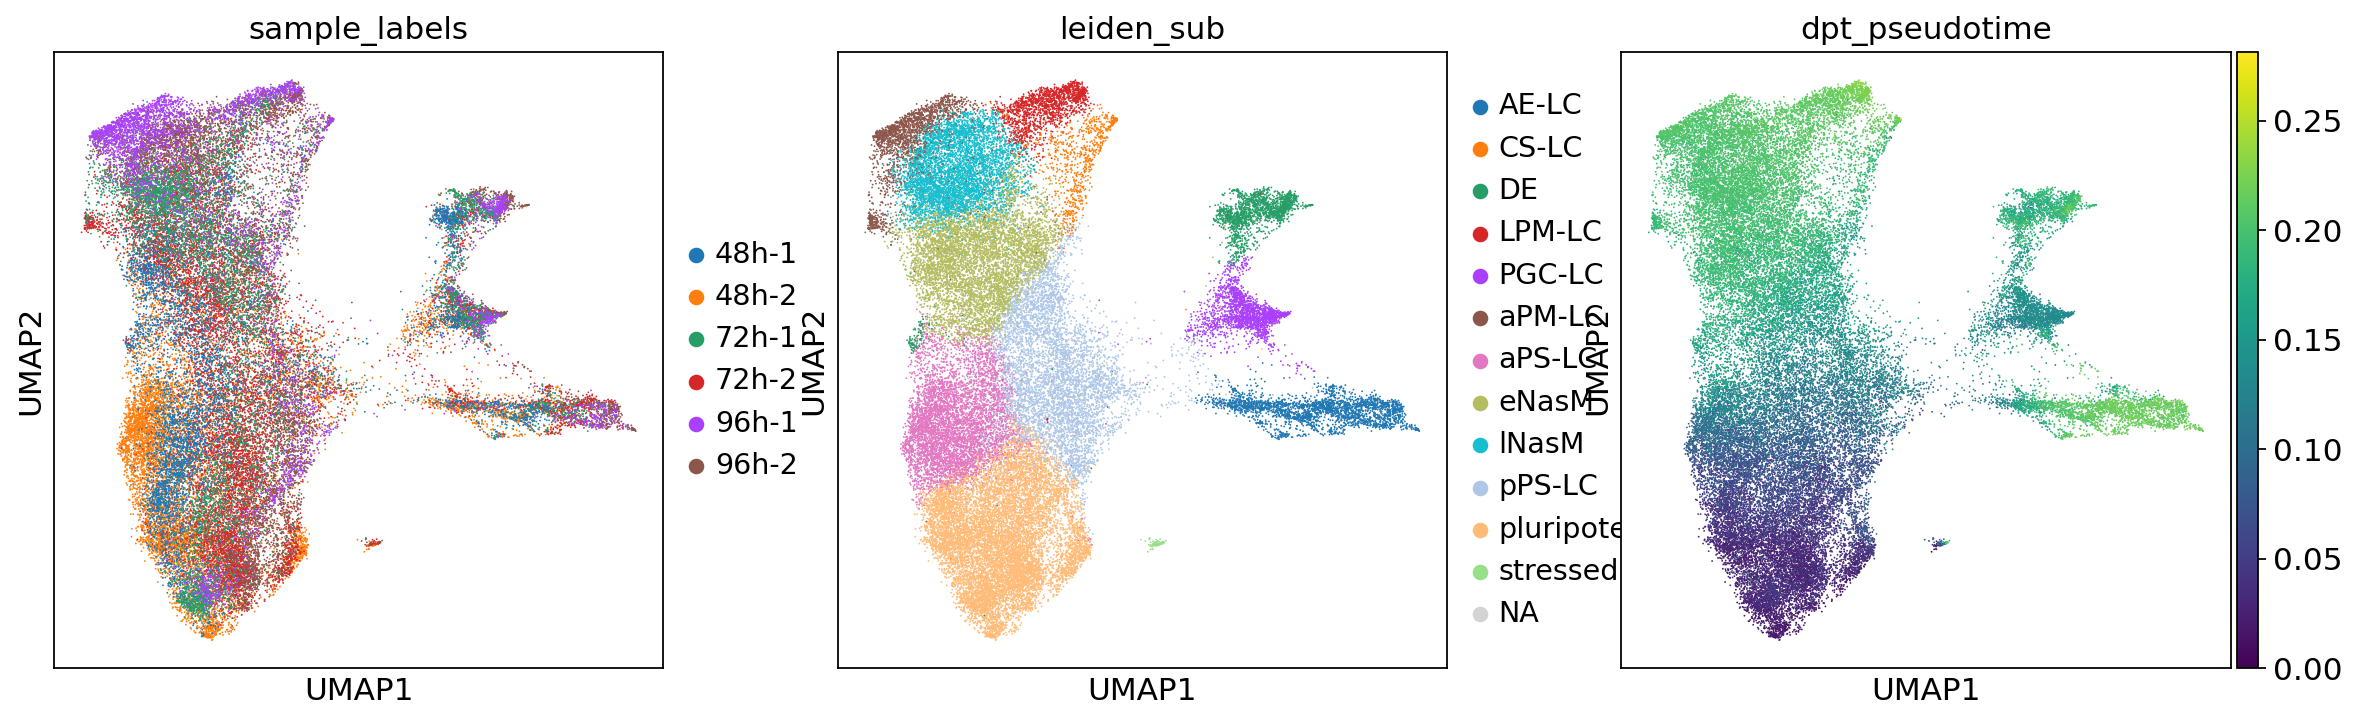

In [39]:
sc.pl.umap(adata, color=["sample_labels", "leiden_sub", "dpt_pseudotime"])

anndata.X is pure counts

In [41]:
print(adata.X[:10, :10].toarray())

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 3. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 3. 2. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 3. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 3. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 2. 0. 0. 0.]
 [0. 0. 1. 0. 0. 3. 4. 0. 0. 1.]
 [0. 0. 0. 0. 0. 4. 4. 0. 0. 1.]
 [0. 0. 2. 0. 0. 3. 0. 0. 0. 1.]]


In [42]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

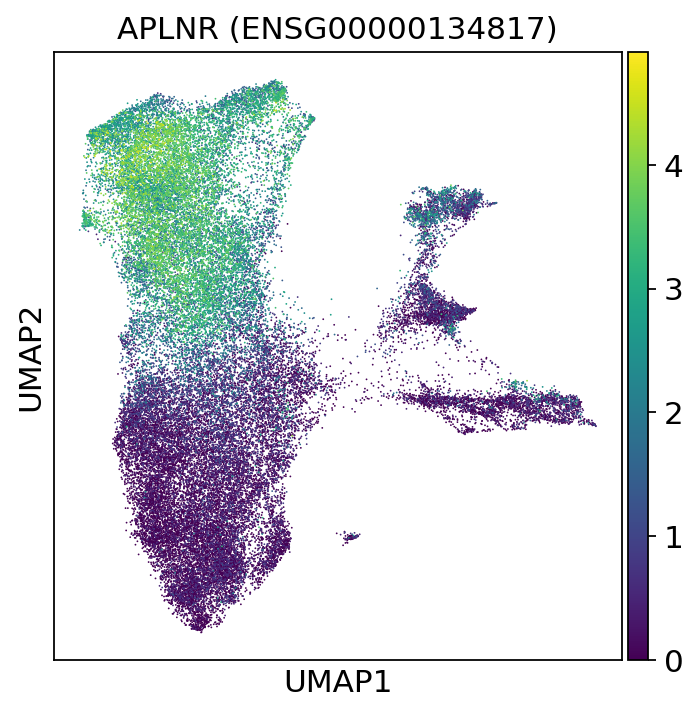

In [43]:
sc.pl.umap(adata, color=adata.var_names[adata.var_names.str.contains("APLNR")])